In [8]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

In [9]:
train_df = pd.read_csv('TRAIN.csv')
test_df = pd.read_csv('TEST.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}\n")

# Check class balance
print("Class Distribution in Training Data:")
print(train_df['Class'].value_counts(normalize=True) * 100)

Training data shape: (43776, 48)
Testing data shape: (10944, 48)

Class Distribution in Training Data:
Class
0    60.455501
1    39.544499
Name: proportion, dtype: float64


Top 10 features most correlated with a Fault (Class 1):
F01    0.386981
F09    0.377363
F29    0.364944
F19    0.358187
F21    0.344699
F05    0.342236
F25    0.338634
F07    0.334932
F27    0.334544
F06    0.330080
Name: Class, dtype: float64


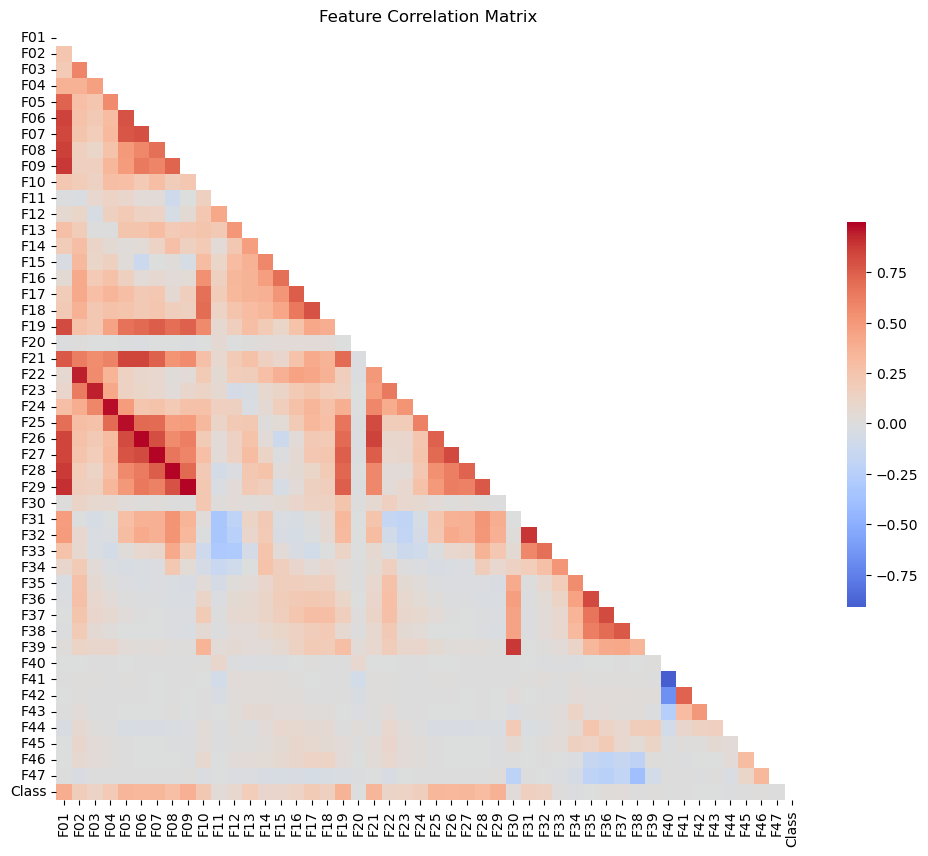

In [10]:
# Calculating correlation with the target class to see which features matter most
print("Top 10 features most correlated with a Fault (Class 1):")
target_corr = train_df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print(target_corr.head(10))

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(train_df.corr(), dtype=bool))
sns.heatmap(train_df.corr(), mask=mask, cmap='coolwarm', center=0, cbar_kws={"shrink": .5})
plt.title('Feature Correlation Matrix')
plt.show()

In [11]:
# Separate features (X) and target (y)
X = train_df.drop(columns=['Class'])
y = train_df['Class']

# Drop the 'ID' column if it exists in the training set 
if 'ID' in X.columns:
    X = X.drop(columns=['ID'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")

Training features shape: (35020, 47)
Validation features shape: (8756, 47)


In [12]:
# Initialize the model with F1-boosting parameters
model = RandomForestClassifier(
    n_estimators=300, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

# Train the model
print("Training the Random Forest model...")
model.fit(X_train, y_train)
print("Training completed successfully!")

Training the Random Forest model...
Training completed successfully!


------ Model Evaluation Metrics ------
Accuracy:  0.9850
Precision: 0.9973
Recall:    0.9648
F1 Score:  0.9808
ROC AUC:   0.9995

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      5293
           1       1.00      0.96      0.98      3463

    accuracy                           0.99      8756
   macro avg       0.99      0.98      0.98      8756
weighted avg       0.99      0.99      0.98      8756



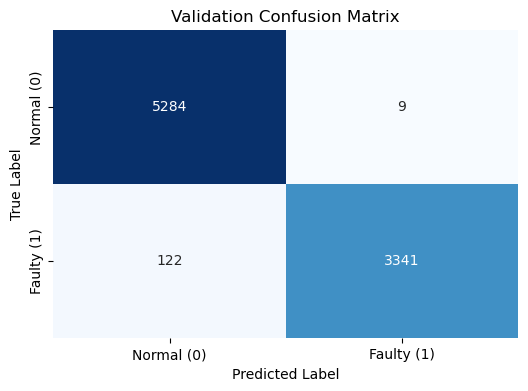

In [13]:
# Predict classes and probabilities
val_preds = model.predict(X_val)
val_probs = model.predict_proba(X_val)[:, 1]

accuracy = accuracy_score(y_val, val_preds)
precision = precision_score(y_val, val_preds)
recall = recall_score(y_val, val_preds)
f1 = f1_score(y_val, val_preds)
roc_auc = roc_auc_score(y_val, val_probs)

print("------ Model Evaluation Metrics ------")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_val, val_preds))

# Confusion Matrix
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'Faulty (1)'],
            yticklabels=['Normal (0)', 'Faulty (1)'])

plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [15]:
test_ids = test_df['ID']

X_test = test_df.drop(columns=['ID'])

print("Generating predictions for the test set...")
test_predictions = model.predict(X_test)

# Creating the final dataframe
submission_df = pd.DataFrame({
    'ID': test_ids,
    'CLASS': test_predictions
})

# Save to CSV without the index column
submission_df.to_csv('final.csv', index=False)

print("'final.csv' has been generated successfully")
submission_df.head()

Generating predictions for the test set...
'final.csv' has been generated successfully


,ID,CLASS
0,1,1
1,2,0
2,3,1
3,4,0
4,5,0
